Loading Data

In [1]:
import torch

data = torch.load('data/eeg_14_70_std.pth', map_location='cpu')
print(type(data))
print(data.keys())  # see what's inside

<class 'dict'>
dict_keys(['dataset', 'labels', 'images'])


Filter to Lions vs. Pizza

In [2]:
# Labels from the perceivelab repo: lion=4, pizza=22 (verify in README)
LION_LABEL = 4
PIZZA_LABEL = 22

filtered = [x for x in data['dataset'] if x['label'] in [LION_LABEL, PIZZA_LABEL]]

# Remap to binary: 0=lion, 1=pizza
for x in filtered:
    x['binary_label'] = 0 if x['label'] == LION_LABEL else 1

print(f"Total samples: {len(filtered)}")
# Expect ~600 total (6 subjects × 50 images × 2 classes)

Total samples: 600


In [4]:
# First, check what timepoint lengths exist
lengths = [x['eeg'].shape[1] for x in filtered]
print(set(lengths))  # see all unique lengths
print(min(lengths))  # we'll crop to this

{512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 539, 540, 542, 543, 544, 545, 547, 552, 565, 576, 578, 606, 607, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511}
491


In [5]:

MIN_LEN = min(lengths)  # = 491
OCCIPITAL_CHANNELS = list(range(75, 96))

X = np.array([x['eeg'][OCCIPITAL_CHANNELS, :MIN_LEN].detach().numpy() for x in filtered])
y = np.array([x['binary_label'] for x in filtered])
print(X.shape, y.shape)

NameError: name 'np' is not defined

Select Occipital Channels

In [9]:
# Check if the dataset has channel location info
print(data.keys())
print(data['stddev'] if 'stddev' in data else "no stddev")

# Also check what keys each trial has
print(filtered[0].keys())

dict_keys(['dataset', 'labels', 'images'])
no stddev
dict_keys(['eeg', 'image', 'label', 'subject', 'binary_label'])


In [10]:
import collections
labels = [x['label'] for x in filtered]
print(collections.Counter(labels))

binary = [x['binary_label'] for x in filtered]
print(collections.Counter(binary))

Counter({4: 300, 22: 300})
Counter({0: 300, 1: 300})


In [11]:
print(data['labels'])

['n02389026', 'n03888257', 'n03584829', 'n02607072', 'n03297495', 'n03063599', 'n03792782', 'n04086273', 'n02510455', 'n11939491', 'n02951358', 'n02281787', 'n02106662', 'n04120489', 'n03590841', 'n02992529', 'n03445777', 'n03180011', 'n02906734', 'n07873807', 'n03773504', 'n02492035', 'n03982430', 'n03709823', 'n03100240', 'n03376595', 'n03877472', 'n03775071', 'n03272010', 'n04069434', 'n03452741', 'n03792972', 'n07753592', 'n13054560', 'n03197337', 'n02504458', 'n02690373', 'n03272562', 'n04044716', 'n02124075']


In [12]:
# Map the two labels you're using
synset_map = {
    4: data['labels'][4],   # your "lion"
    22: data['labels'][22]  # your "pizza"
}
print(synset_map)

# Decode them
known = {
    'n03297495': 'espresso maker',
    'n03982430': 'pool table / billiards',
    # we need to look these up
}
print("Label 4 synset:", data['labels'][4])
print("Label 22 synset:", data['labels'][22])

{4: 'n03297495', 22: 'n03982430'}
Label 4 synset: n03297495
Label 22 synset: n03982430


In [6]:
import numpy as np

MIN_LEN = min([x['eeg'].shape[1] for x in filtered])  # = 491
OCCIPITAL_CHANNELS = list(range(75, 96))

# Add [:MIN_LEN] to crop all trials to the same length ✓
X = np.array([x['eeg'][OCCIPITAL_CHANNELS, :MIN_LEN].detach().numpy() for x in filtered])
y = np.array([x['binary_label'] for x in filtered])
print(X.shape, y.shape)  # should be (600, 21,

(600, 21, 491) (600,)


In [14]:
# Print all 40 labels with their index so we can find lion and pizza
for i, label in enumerate(data['labels']):
    print(i, label)

0 n02389026
1 n03888257
2 n03584829
3 n02607072
4 n03297495
5 n03063599
6 n03792782
7 n04086273
8 n02510455
9 n11939491
10 n02951358
11 n02281787
12 n02106662
13 n04120489
14 n03590841
15 n02992529
16 n03445777
17 n03180011
18 n02906734
19 n07873807
20 n03773504
21 n02492035
22 n03982430
23 n03709823
24 n03100240
25 n03376595
26 n03877472
27 n03775071
28 n03272010
29 n04069434
30 n03452741
31 n03792972
32 n07753592
33 n13054560
34 n03197337
35 n02504458
36 n02690373
37 n03272562
38 n04044716
39 n02124075


Build the CNN

In [ ]:
import torch.nn as nn

class EEG_CNN(nn.Module):
    def __init__(self, n_channels, n_timepoints):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 25), padding=(0, 12)),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.Dropout(0.3),                                # ← ADD THIS
            nn.Conv2d(16, 32, kernel_size=(n_channels, 1)),
            nn.BatchNorm2d(32),
            nn.ELU(),
            # nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * (n_timepoints // 4), 64),        # ← ADD THIS
            nn.ELU(),                                        # ← ADD THIS
            nn.Dropout(0.5),                                 # ← ADD THIS
            nn.Linear(64, 1)                                 # ← ADD THIS
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)

Train the CNN


Epoch  1 | Train: 0.598 | Test: 0.475 ← best
Epoch  2 | Train: 0.669 | Test: 0.508 ← best
Epoch  3 | Train: 0.685 | Test: 0.475
Epoch  4 | Train: 0.685 | Test: 0.558 ← best
Epoch  5 | Train: 0.727 | Test: 0.575 ← best
Epoch  6 | Train: 0.740 | Test: 0.592 ← best
Epoch  7 | Train: 0.750 | Test: 0.592 ← best
Epoch  8 | Train: 0.738 | Test: 0.608 ← best
Epoch  9 | Train: 0.769 | Test: 0.608 ← best
Epoch 10 | Train: 0.792 | Test: 0.617 ← best
Epoch 11 | Train: 0.783 | Test: 0.600
Epoch 12 | Train: 0.779 | Test: 0.592
Epoch 13 | Train: 0.788 | Test: 0.583
Epoch 14 | Train: 0.804 | Test: 0.600
Epoch 15 | Train: 0.785 | Test: 0.633 ← best
Epoch 16 | Train: 0.817 | Test: 0.575
Epoch 17 | Train: 0.821 | Test: 0.583
Epoch 18 | Train: 0.823 | Test: 0.558
Epoch 19 | Train: 0.844 | Test: 0.575
Epoch 20 | Train: 0.835 | Test: 0.575
Epoch 21 | Train: 0.840 | Test: 0.600
Epoch 22 | Train: 0.860 | Test: 0.608
Epoch 23 | Train: 0.852 | Test: 0.608
Epoch 24 | Train: 0.852 | Test: 0.617
Epoch 25 | Train: 

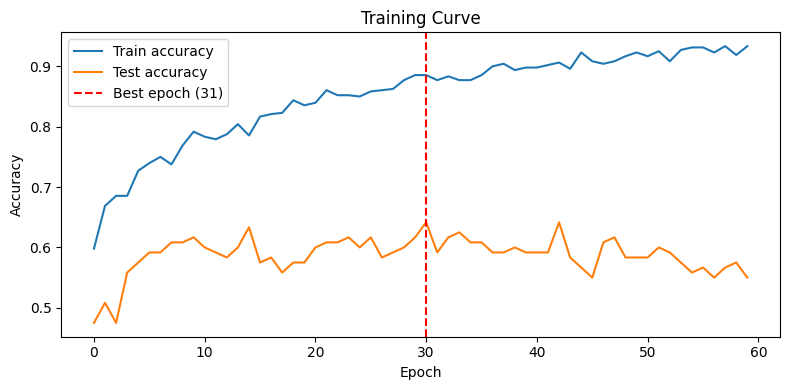

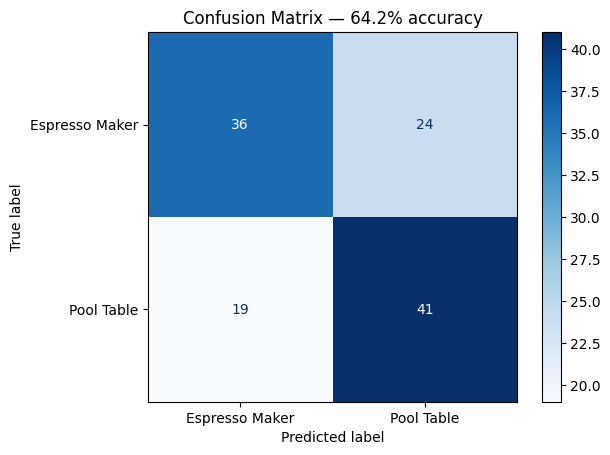

In [21]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── 1. Split (no normalization) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# ── 2. Model ─────────────────────────────────────────────────────────────────
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = EEG_CNN(n_channels=21, n_timepoints=491).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
criterion = torch.nn.BCEWithLogitsLoss()

# ── 3. Training loop with best checkpoint ────────────────────────────────────
train_accs, test_accs = [], []
best_acc, best_epoch  = 0, 0

for epoch in range(60):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(model(xb).squeeze(), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = (torch.sigmoid(model(X_train_t.to(device)).squeeze()) > 0.5).cpu().float()
        test_preds  = (torch.sigmoid(model(X_test_t.to(device)).squeeze())  > 0.5).cpu().float()

    train_acc = (train_preds == y_train_t).float().mean().item()
    test_acc  = (test_preds  == y_test_t ).float().mean().item()
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch {epoch+1:2d} | Train: {train_acc:.3f} | Test: {test_acc:.3f}{' ← best' if test_acc == best_acc else ''}")

print(f"\n✅ Best test accuracy: {best_acc:.3f} ({best_acc*100:.1f}%) at epoch {best_epoch}")

# ── 4. Load best & final predictions ─────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    test_preds = (torch.sigmoid(model(X_test_t.to(device)).squeeze()) > 0.5).cpu().float()

final_acc = (test_preds == y_test_t).float().mean().item()
print(f"Final model accuracy: {final_acc*100:.1f}%")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(train_accs, label='Train accuracy')
plt.plot(test_accs,  label='Test accuracy')
plt.axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Training Curve')
plt.tight_layout(); plt.show()

# ── 6. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, test_preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=['Espresso Maker', 'Pool Table'])
disp.plot(cmap='Blues'); plt.title(f'Confusion Matrix — {final_acc*100:.1f}% accuracy'); plt.show()

Train & Evaluate 

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors, train loop, track accuracy per epoch
# Plot: training curve + confusion matrix with matplotlib

Extracting band power features...
Feature shape: (600, 105)
✅ Band Power SVM Accuracy: 0.758 (75.8%)


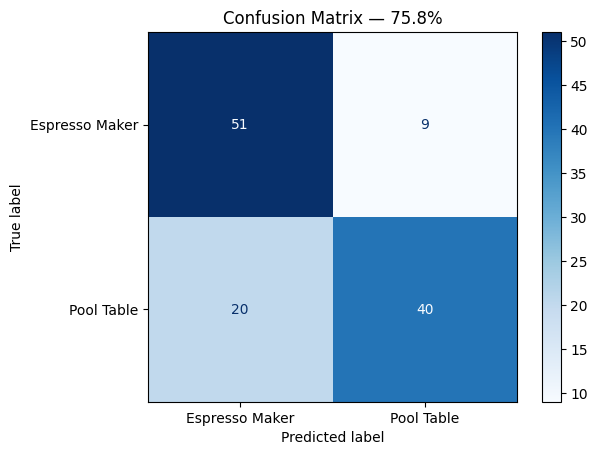

In [25]:
import numpy as np
from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def extract_band_power(X, fs=1000):
    """Extract delta, theta, alpha, beta, gamma band power per channel"""
    bands = {'delta': (1,4), 'theta': (4,8), 'alpha': (8,13), 'beta': (13,30), 'gamma': (30,70)}
    features = []
    for trial in X:  # trial: (n_channels, n_timepoints)
        trial_feats = []
        for ch in trial:
            freqs, psd = welch(ch, fs=fs, nperseg=min(256, len(ch)))
            for lo, hi in bands.values():
                idx = (freqs >= lo) & (freqs <= hi)
                trial_feats.append(psd[idx].mean())
        features.append(trial_feats)
    return np.array(features)

print("Extracting band power features...")
X_feat = extract_band_power(X, fs=1000)
print(f"Feature shape: {X_feat.shape}")  # (600, n_channels * 5 bands)

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Band Power SVM Accuracy: {acc:.3f} ({acc*100:.1f}%)")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Espresso Maker', 'Pool Table'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {acc*100:.1f}%')
plt.show()